In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("amazon.csv")

In [4]:
print(df.head())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

In [5]:
print(f"The Number of Rows are {df.shape[0]}, and columns are {df.shape[1]}.")

The Number of Rows are 1465, and columns are 16.


In [6]:
print(df.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [8]:
print(df[['discounted_price', 'discount_percentage', 'rating_count']].head(3))

  discounted_price discount_percentage rating_count
0             ₹399                 64%       24,269
1             ₹199                 43%       43,994
2             ₹199                 90%        7,928


In [9]:
df["discounted_price"] = df["discounted_price"].str.replace("₹", "").str.replace(",", "").astype(float)

In [10]:
df["discount_percentage"] = df["discount_percentage"].str.replace("%", "").astype(float)

In [11]:
df['rating_count'] = df['rating_count'].str.replace(',', '').astype('float64')

In [12]:
print("\n--- Değişim Sonrası Veri Tipleri ---")
print(df[['discounted_price', 'discount_percentage', 'rating_count']].dtypes)


--- Değişim Sonrası Veri Tipleri ---
discounted_price       float64
discount_percentage    float64
rating_count           float64
dtype: object


In [13]:
print(df[['rating','actual_price']].head(3))

  rating actual_price
0    4.2       ₹1,099
1    4.0         ₹349
2    3.9       ₹1,899


In [14]:
# 1. Gerçek Fiyatı temizleme (Aynı indirimli fiyata yaptığımız gibi)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

In [15]:
# 2. Rating (Puan) sütununu doğrudan ondalıklı sayıya çevirme denemesi
# df['rating'] = df['rating'].astype(float)
# ValueError: could not convert string to float: '|'

# Finding unusual string in rating column
df['rating'].value_counts()

rating
4.1    244
4.3    230
4.2    228
4.0    129
3.9    123
4.4    123
3.8     86
4.5     75
4       52
3.7     42
3.6     35
3.5     26
4.6     17
3.3     16
3.4     10
4.7      6
3.1      4
3.0      3
4.8      3
5.0      3
2.8      2
3.2      2
2.3      1
|        1
2        1
3        1
2.6      1
2.9      1
Name: count, dtype: int64

In [16]:
# Check the strange row
df.query('rating == "|"')

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,16.0,|,992.0,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [17]:
# Hata veren astype(float) yerine, hataları NaN'a çeviren to_numeric kullanıyoruz
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [18]:
# Dönüşüm başarılı oldu mu bakalım? (rating artık float64 olmalı)
print(df['rating'].dtypes)

# Peki o '|' işareti NaN'a dönüşmüş mü? Eksik verileri tekrar saydıralım:
print("\n--- Yeni Çıkan Eksik Veriler (NaN) ---")
print(df.isnull().sum())

float64

--- Yeni Çıkan Eksik Veriler (NaN) ---
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [20]:
# 1. Puan (rating) sütunundaki 1 eksiği, tüm ürünlerin puan ORTALAMASI ile dolduralım
df["rating"] = df["rating"].fillna(df["rating"].mean())

# 2. Oylanma Sayısı (rating_count) sütunundaki 2 eksiği, ORTANCA (median) ile dolduralım
# (Neden median? Çünkü e-ticarette bazı ürünler 100.000 yorum alırken bazıları 5 yorum alır. 
# Ortalama yanıltıcı olur, ortanca en güvenlisidir.)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

In [21]:
# 3. Son kontrol! Artık her şey sıfır olmalı.
print("\n--- Değişim Sonrası Eksik Veriler ---")
print(df.isnull().sum())


--- Değişim Sonrası Eksik Veriler ---
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [22]:
# Find Duplicate
df.duplicated().any()

np.False_

In [23]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [24]:
any_duplicates = df.duplicated(subset=['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link']).any()

In [25]:
any_duplicates

np.False_

In [26]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,3125.310874,5444.990635,47.691468,4.096585,18277.634812
std,6944.304394,10874.826864,21.635905,0.291574,42727.398216
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1191.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17325.000000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [27]:
# dont show warnings
import warnings
warnings.filterwarnings('ignore')

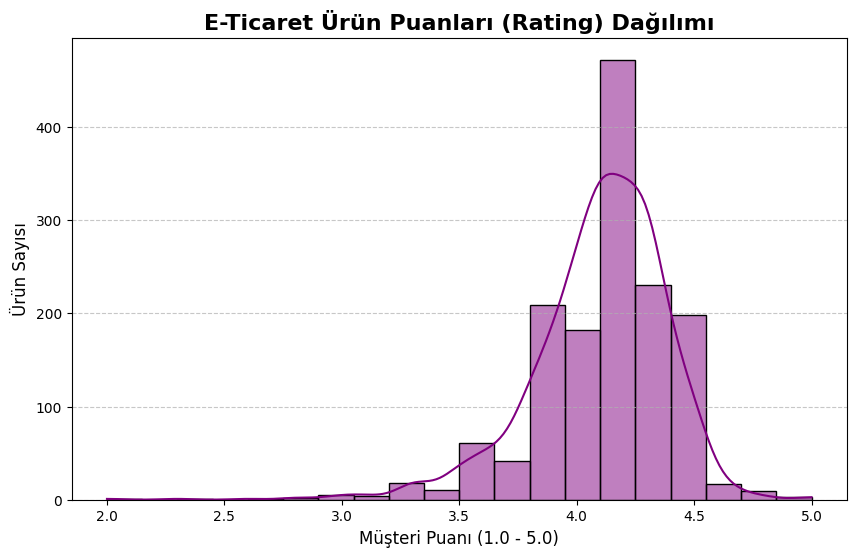

In [28]:
# 1. Tuvalin (Figure) boyutunu profesyonel bir ölçüye (Genişlik: 10, Yükseklik: 6) ayarlıyoruz
plt.figure(figsize=(10, 6))

# 2. Seaborn ile şık bir Histogram çiziyoruz
# kde=True parametresi, o sütunların üzerine yumuşak bir trend çizgisi (yoğunluk eğrisi) çizer
sns.histplot(data=df, x='rating', bins=20, kde=True, color='purple')

# 3. Grafiğe başlık ve eksen isimleri ekleyip estetik katıyoruz
plt.title("E-Ticaret Ürün Puanları (Rating) Dağılımı", fontsize=16, fontweight='bold')
plt.xlabel("Müşteri Puanı (1.0 - 5.0)", fontsize=12)
plt.ylabel("Ürün Sayısı", fontsize=12)

# 4. Arka plana şık bir ızgara (grid) ekleyip grafiği ekrana basıyoruz
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Bu sitede satılan ürünlerin genel kalite algısı çok yüksek ya da bu sitenin müşterileri ürünlere düşük puan vermeye pek meyilli değil.

Müşteriler Çok Cömert: Ürünlerin ezici bir çoğunluğu 4.0 ile 4.5 puan arasına yığılmış. En büyük zirve (tepe noktası) 4.1 - 4.2 civarında yaşanıyor.

Kötü Ürün Neredeyse Yok: Grafiğin sol tarafına bakarsan, 3.5 puanın altında kalan ürün sayısının yok denecek kadar az olduğunu görürsün.

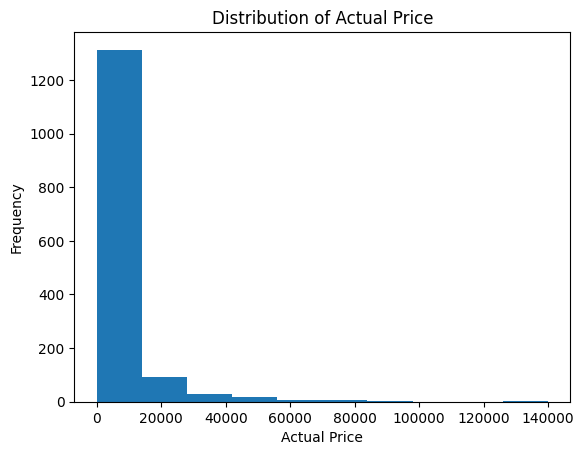

In [29]:
# Plot distribution of actual_price
plt.hist(df['actual_price']) # Gerçek Fiyatın dağılımına bakalım
plt.xlabel('Actual Price')
plt.ylabel('Frequency')
plt.title('Distribution of Actual Price')
plt.show()

Ucuz Ürün Cenneti: Ürünlerin ezici bir çoğunluğu (yaklaşık 1300 tanesi) grafiğin en solunda, yani en düşük fiyat aralığında (0 - 20.000 aralığı) devasa bir gökdelen oluşturmuş. Sitedeki ürünlerin çoğu "uygun fiyatlı".

Lüks Ürünler Çok Nadir: Grafiğin sağ tarafına doğru uzanan o dümdüz, incecik çizgiye dikkat et. 100.000 - 140.000 bandında tek tük ürünler var (muhtemelen üst düzey bilgisayarlar veya dev ekran televizyonlar). Bunlar tablomuzun "aykırı değerleri" (outliers).

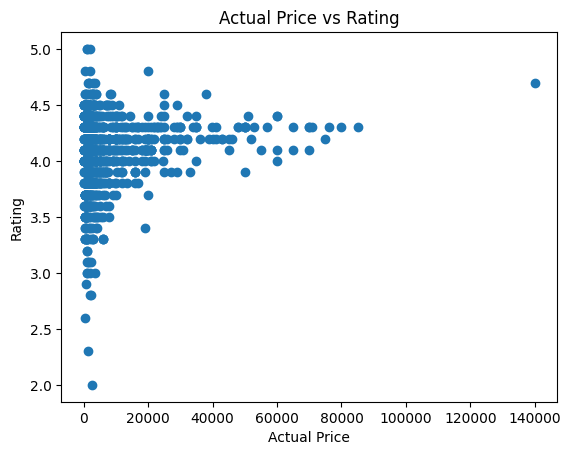

In [30]:
 # Gerçek Fiyat ile Puan arasında bir ilişki var mı bakalım
plt.scatter(df['actual_price'], df['rating']) 
plt.xlabel('Actual Price')
plt.ylabel('Rating')
plt.title('Actual Price vs Rating')
plt.show()

Ucuzlukta Her Şey Mümkün (Sol Taraf): Grafiğin sol tarafındaki o devasa mavi duvara bak. Fiyatı 0 - 20.000 bandında olan ürünlerin puanları 2'den 5'e kadar her yere saçılmış. Yani ucuz bir ürün tam bir çöp de (2 yıldız) çıkabilir, harika bir fiyat/performans canavarı da (5 yıldız) olabilir. Fiyat burada kaliteyi asla garanti etmiyor.

Pahalılık Bir "Güvenlik Ağıdır" (Sağ Taraf): Fiyat 40.000, 80.000 ve ötesine geçtikçe grafiğin alt kısmı (2 ve 3 yıldız bölgesi) tamamen boşalıyor! 40.000'den pahalı olup da 4.0'ın altında puan alan neredeyse hiçbir ürün yok.

Müşteriye şunu çok net söyleyebiliriz: "Sitemizde çok ucuza 5 yıldızlı efsane ürünler bulabilirsiniz. Ancak yüksek bir meblağ (örneğin 60.000) öderseniz, o ürünün kötü çıkma ihtimali neredeyse sıfırdır."

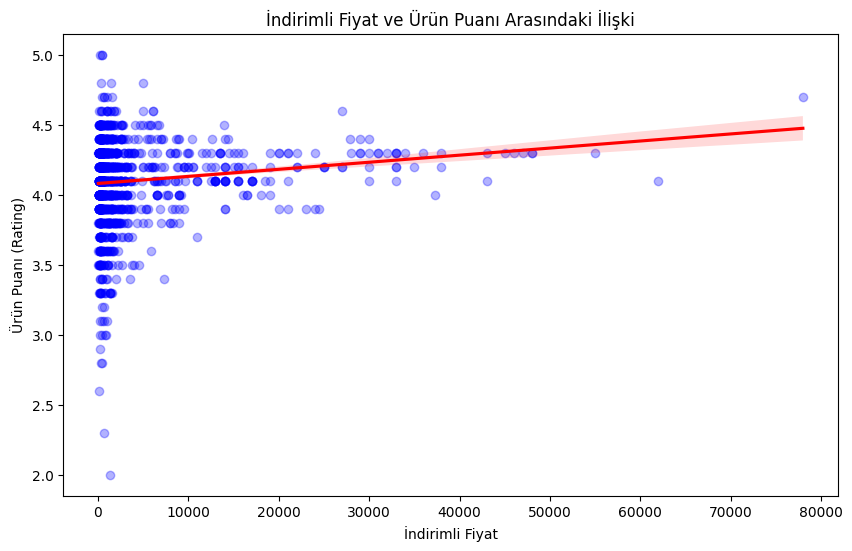

In [31]:
# Grafiğin boyutunu ayarlayalım
plt.figure(figsize=(10, 6))

# Seaborn'un regplot fonksiyonu hem noktaları hem de eğilim çizgisini çizer
sns.regplot(data=df, x='discounted_price', y='rating', 
            scatter_kws={'alpha':0.3, 'color':'blue'}, # Noktaları hafif şeffaf yapalım ki üst üste binenler görülsün
            line_kws={'color':'red'}) # Eğilim çizgisini kırmızı yapalım

# Başlık ve eksen etiketlerini ekleyelim
plt.title('İndirimli Fiyat ve Ürün Puanı Arasındaki İlişki')
plt.xlabel('İndirimli Fiyat')
plt.ylabel('Ürün Puanı (Rating)')

# Grafiği gösterelim
plt.show()

"Ürünün etiket fiyatı arttıkça puanı artıyor mu?" Yani parayı veren düdüğü çalıyor mu?

Çizgi YUKARI Bakıyor (Pozitif Korelasyon): Fiyat arttıkça puanlar da hafifçe yükseliyor. Bu bize, pahalı ürünlerin genellikle daha kaliteli algılandığını veya daha az sorun çıkardığını gösteriyor.

Noktalar sol tarafa (ucuz ürünlere) hapsolmuş durumda. Pahalı ürünlere doğru gittikçe veri seyrekleşiyor. Bu, sitemizin daha çok "uygun fiyatlı" ürün sattığını kanıtlar.

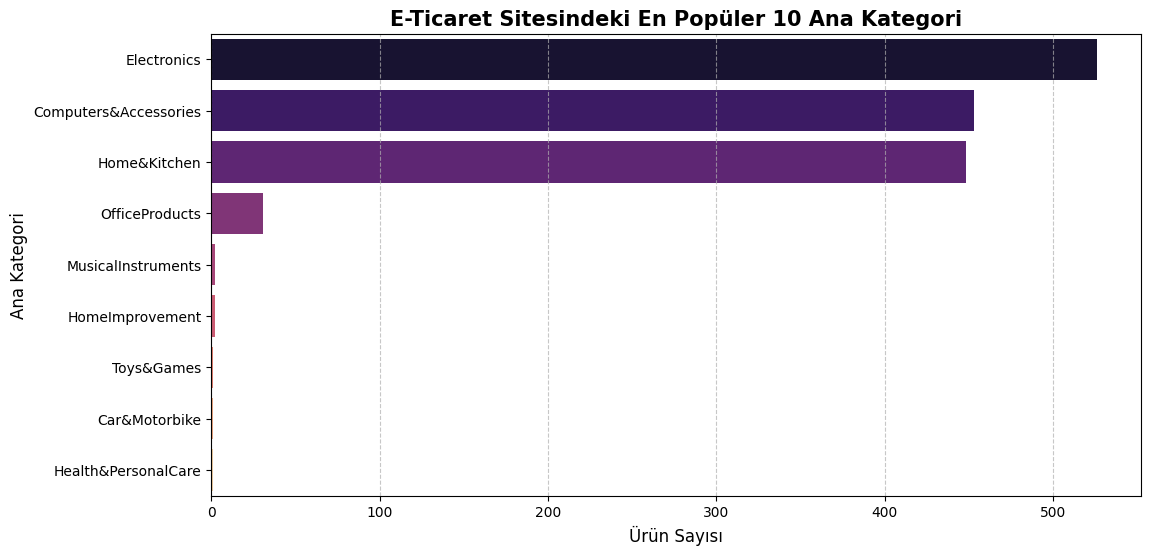

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kategori Kırpma Ameliyatı: Metni '|' işaretinden böl ve ilk parçayı ([0]) al!
df['main_category'] = df['category'].str.split('|').str[0]

# 2. Hangi ana kategoriden kaç tane ürün var sayalım ve ilk 10 tanesini alalım
top_10_kategori = df['main_category'].value_counts().head(10)

# 3. Görselleştirme Şovu Başlıyor
plt.figure(figsize=(12, 6))
# x eksenine ürün sayısını, y eksenine kategori isimlerini veriyoruz (Yatay Bar Grafiği)
sns.barplot(x=top_10_kategori.values, y=top_10_kategori.index, palette='magma')

# 4. Grafiğe estetik katıyoruz
plt.title("E-Ticaret Sitesindeki En Popüler 10 Ana Kategori", fontsize=15, fontweight='bold')
plt.xlabel("Ürün Sayısı", fontsize=12)
plt.ylabel("Ana Kategori", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Büyük Üçlü'nün Hükümdarlığı: Sitenin kalbi açık ara Electronics (Elektronik), Computers & Accessories (Bilgisayar ve Aksesuarları) ve Home & Kitchen (Ev ve Mutfak) kategorilerinde atıyor. Sadece bu üçlü, sitenin vitrininin neredeyse %90'ını oluşturuyor.

Devasa Uçurum: İlk 3 kategoriden sonra inanılmaz bir düşüş (uçurum) var. 4. sıradaki "Office Products" (Ofis Ürünleri) zar zor 50 ürüne ulaşırken; Müzik Aletleri, Oyuncaklar veya Sağlık ürünleri grafikte kıl inceliğinde kalmış. Neredeyse yok gibiler.

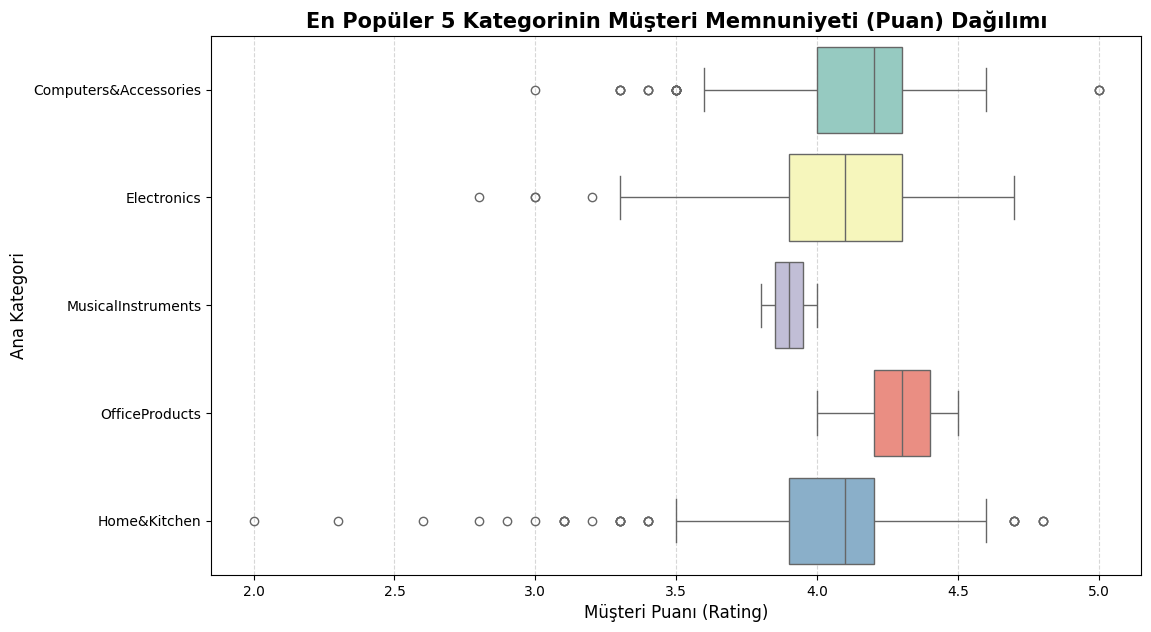

In [33]:
# 1. Karmaşayı önlemek için en popüler 5 ana kategorinin ismini bir listeye alıyoruz
en_populer_5_kategori = df['main_category'].value_counts().head(5).index 
# Kimlerin "en büyük" olduğuna karar verme aşamasıdır (Sadece isimleri seçer).

# 2. Tablomuzu SADECE bu 5 kategoriye ait ürünler kalacak şekilde filtreliyoruz
df_top5 = df[df['main_category'].isin(en_populer_5_kategori)]
# isin() (is in), "içinde mi?" anlamına gelir. 
# O isimlere ait olan tüm verileri (puan, fiyat vb.) dev tablodan süzüp çıkarma aşamasıdır.

# 3. Görselleştirme Şovu: Kutu Grafiği (Boxplot)
plt.figure(figsize=(12, 7))

# y ekseninde kategoriler, x ekseninde puanlar. 
sns.boxplot(data=df_top5, y='main_category', x='rating', palette='Set3')

# 4. Estetik ve UI Dokunuşları
plt.title("En Popüler 5 Kategorinin Müşteri Memnuniyeti (Puan) Dağılımı", fontsize=15, fontweight='bold')
plt.xlabel("Müşteri Puanı (Rating)", fontsize=12)
plt.ylabel("Ana Kategori", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

En İstikrarlı Kategori (Office Products): Kırmızı kutuya bak! Hem çok dar (yani ürünlerin çoğu birbirine yakın, yüksek puanlar almış) hem de neredeyse hiç "çürük yumurta" (aykırı değer) yok. Müşteriler bu kategoriden ne alacağını biliyor ve mutlu ayrılıyor.

En Riskli Kategori (Home & Kitchen): Mavi kutunun soluna doğru uzanan o uzun "kuyruk" ve tek tek duran noktalar (aykırı değerler) tehlike sinyali veriyor. Bu kategoride 2.0 puana kadar düşen çok fazla "sorunlu ürün" var. Ortalama puanı yüksek görünse de, bazı müşteriler çok mutsuz.

Müzik Aletleri (Musical Instruments): Mor kutu çok dar ve yüksekte duruyor. Bu da bu kategorideki ürün sayısının az ama kalitesinin (veya müşteri sadakatinin) çok odaklanmış olduğunu gösteriyor.

Aykırı Değerler (Outliers): Kutuların solunda kalan o minik daireler, kategorinin genel başarısını aşağı çeken ürünlerdir. 

"Acaba Home & Kitchen'daki o 2.0 puanlık ürünler hangi markanın?" sorusunu sorman gereken yer burasıdır.

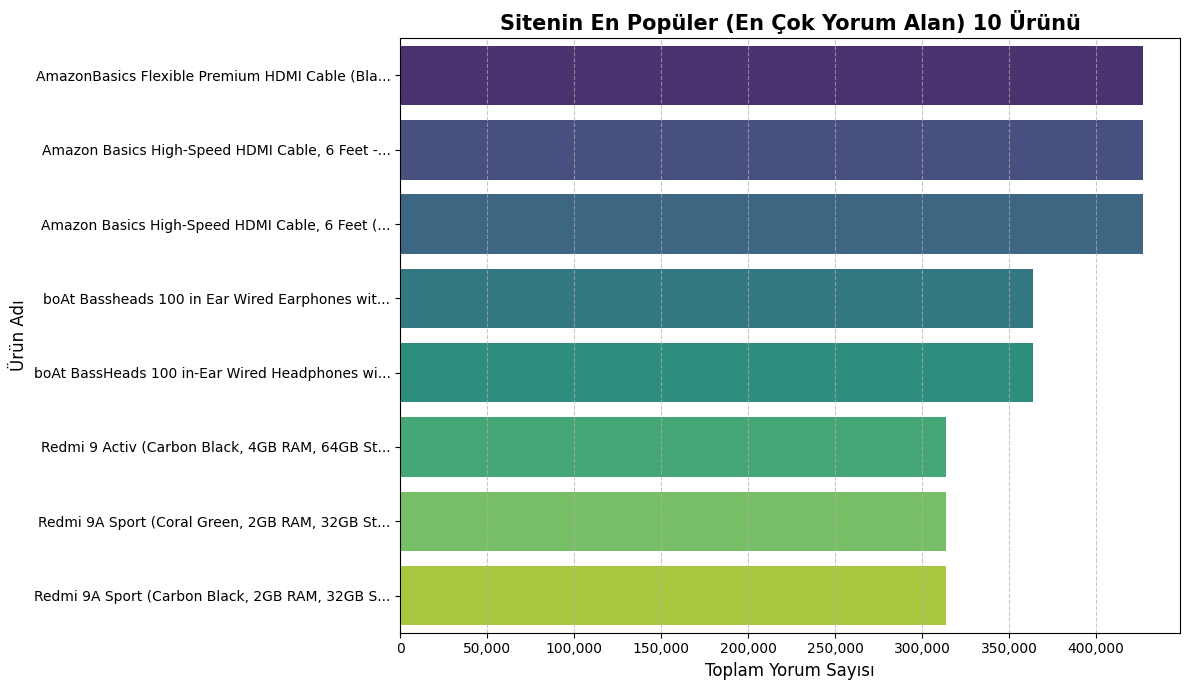

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. En çok yorum alan (rating_count en yüksek) ilk 10 ürünü buluyoruz
top_10_urunler = df.nlargest(10, 'rating_count')

# 2. Ürün isimleri çok uzun olduğu için grafikte çirkin durmasın diye ilk 45 karakterini kesiyoruz
top_10_urunler['kisa_isim'] = top_10_urunler['product_name'].apply(lambda x: x[:45] + '...' if len(str(x)) > 45 else x)

# 3. Görselleştirme Şovu: Yatay Bar Grafiği
plt.figure(figsize=(12, 7))

# x eksenine yorum sayısını, y eksenine kısalttığımız ürün isimlerini veriyoruz
sns.barplot(data=top_10_urunler, x='rating_count', y='kisa_isim', palette='viridis')

# 4. Estetik Dokunuşlar
plt.title("Sitenin En Popüler (En Çok Yorum Alan) 10 Ürünü", fontsize=15, fontweight='bold')
plt.xlabel("Toplam Yorum Sayısı", fontsize=12)
plt.ylabel("Ürün Adı", fontsize=12)

# X eksenindeki sayıları (milyonları vs.) düzgün okumak için virgüllü formata çeviriyoruz
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # İsimler ekrana tam sığsın diye grafiği sıkıştırır
plt.show()

Aksesuar Krallığı: Listenin en başında (yaklaşık 425.000 yorum ile) AmazonBasics HDMI kabloları ve boAt kulaklıklar oturuyor. Bu bize şunu söylüyor: İnsanlar en çok, herkesin ihtiyacı olan, nispeten ucuz ve "sarf malzemesi" niteliğindeki aksesuarlara yorum bırakıyor.

Akıllı Telefon Etkisi: Listenin alt yarısını Redmi (Xiaomi) marka telefonlar domine etmiş. Her biri 300.000 barajını aşmış durumda. Bu da sitenin akıllı telefon pazarında çok güçlü bir oyuncu olduğunu gösteriyor.

Hacim vs. Çeşitlilik: Dikkat edersen ilk 10 ürün sadece 3-4 farklı markadan (AmazonBasics, boAt, Redmi) oluşuyor. Yani popülerlik belirli dev markaların elinde toplanmış durumda.

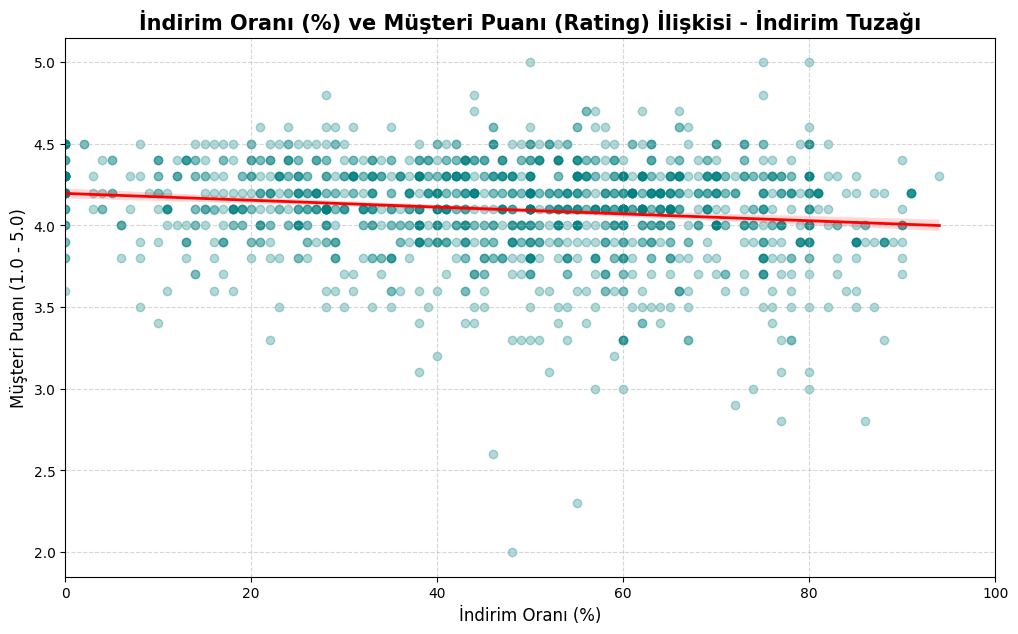

In [35]:
# 1. Görselleştirme Tuvalini hazırlıyoruz
plt.figure(figsize=(12, 7))

# 2. Seaborn'un 'regplot' fonksiyonu, hem noktaları çizer hem de aralarındaki trendi bulur
# scatter_kws ile noktaların şeffaflığını (alpha) ayarlıyoruz ki üst üste binenleri görebilelim
# line_kws ile trend çizgisinin rengini (kırmızı) belirliyoruz
sns.regplot(data=df, x='discount_percentage', y='rating', 
            scatter_kws={'alpha': 0.3, 'color': 'teal'}, 
            line_kws={'color': 'red', 'linewidth': 2})

# 3. Estetik Dokunuşlar
plt.title("İndirim Oranı (%) ve Müşteri Puanı (Rating) İlişkisi - İndirim Tuzağı", fontsize=15, fontweight='bold')
plt.xlabel("İndirim Oranı (%)", fontsize=12)
plt.ylabel("Müşteri Puanı (1.0 - 5.0)", fontsize=12)

# X ekseni yüzde olduğu için 0'dan 100'e kadar sınırlandırıyoruz
plt.xlim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

"İndirimin şiddeti arttıkça (yüzde kaç yapıldığı) puan artıyor mu?" Yani "büyük indirim" müşteriyi mutlu ediyor mu?

Trend Çizgisinin Eğimi: Dikkat edersen kırmızı çizgi sol baştan sağa doğru hafifçe aşağı meyilli. Bu bize şunu söylüyor: İndirim oranı arttıkça, müşteri puanları çok küçük bir miktarda da olsa düşme eğilimi gösteriyor.

İndirim Tuzağı Kanıtı: %80-%90 indirim yapılan bölgeye bak. Orada 3.0 ve altı puanların (noktaların) yoğunlaştığını görebilirsin. Bu, "çok ucuz malın kalitesiz olacağı" yönündeki müşteri algısını veya gerçekten de aşırı indirime giren ürünlerin sorunlu olduğunu kanıtlıyor.

Korelasyon Zayıf: Noktalar çizginin etrafında çok dağınık bir bulut gibi duruyor. Yani indirim oranı, tek başına puanı tahmin etmek için süper bir değişken değil; ama bir "negatif sinyal" taşıdığı ortada.

"Fiyatı yüksek olan ürün kaliteli çıkma eğilimindeyken; indirimi (yüzdesi) aşırı yüksek olan ürün, beklentiyi karşılamayıp düşük puan alma riskine sahip."

In [37]:
# 1. Önce kategorik verileri (metinleri) sayılara (1-0) çevirelim
# Sadece sayısal sütunları ve One-Hot Encoding yapılmış kategorileri tutar
df_model = pd.get_dummies(df, columns=['main_category'], drop_first=True)

# 2. Sadece sayısal ve bool (True/False) olan sütunları seç (Model metin okuyamaz!)
df_model = df_model.select_dtypes(include=['float64', 'int64', 'bool', 'uint8'])

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Hedef (y) ve Girdileri (X) ayırıyoruz
# Not: 'rating' hedefimiz, diğerleri ise tahmin için kullanacağımız özellikler
y = df_model['rating']
X = df_model.drop(columns=['rating'])

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Ölçeklendirme) Ameliyatı
scaler = MinMaxScaler()

# Sadece eğitim setine 'fit' yapıyoruz (öğreniyoruz), sonra her ikisini de 'transform' ediyoruz
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Veri bölündü ve ölçeklendirildi!")
print(f"Eğitim seti boyutu: {X_train_scaled.shape}")
print(f"Test seti boyutu: {X_test_scaled.shape}")

✅ Veri bölündü ve ölçeklendirildi!
Eğitim seti boyutu: (1172, 12)
Test seti boyutu: (293, 12)


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Modeli oluştur (Boş bir beyin gibi düşün)
model = LinearRegression()

# 2. Modeli eğit (Öğrenme süreci burada başlar - .fit)
model.fit(X_train_scaled, y_train)

# 3. Tahmin yap (Bakalım sınavda ne yapacak?)
y_pred = model.predict(X_test_scaled)

print("🚀 Model eğitildi ve tahminler yapıldı!")

🚀 Model eğitildi ve tahminler yapıldı!


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Hata payını ve başarı oranını hesapla
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Ortalama Hata (MAE): {mae:.4f}")
print(f"🎯 Başarı Oranı (R² Score): {r2:.4f}")
print(f"📉 Ortalama Kare Hata (MSE): {mse:.4f}")

# 2. Gerçek Değerler vs Tahminler (İlk 10 tanesine göz atalım)
karsilastirma = pd.DataFrame({'Gerçek Puan': y_test.values[:10], 'Tahmin Edilen': y_pred[:10]})
print("\n🔍 İlk 10 Tahmin Karşılaştırması:")
print(karsilastirma)

📊 Ortalama Hata (MAE): 0.1955
🎯 Başarı Oranı (R² Score): 0.1263
📉 Ortalama Kare Hata (MSE): 0.0713

🔍 İlk 10 Tahmin Karşılaştırması:
   Gerçek Puan  Tahmin Edilen
0          4.6       4.291305
1          3.7       4.116347
2          3.3       3.997639
3          4.3       4.024392
4          4.3       4.187038
5          4.1       4.107866
6          4.1       4.064452
7          3.9       4.097827
8          4.3       4.069962
9          3.6       3.998444


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Modeli oluştur (100 tane ağaçtan oluşan bir orman kuralım)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Modeli eğit
rf_model.fit(X_train_scaled, y_train)

# 3. Tahmin yap
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Metrikleri hesapla
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"🌲 Random Forest Ortalama Hata (MAE): {mae_rf:.4f}")
print(f"🎯 Random Forest Başarı Oranı (R² Score): {r2_rf:.4f}")

# İlk 10 tahmini tekrar görelim
karsilastirma_rf = pd.DataFrame({'Gerçek Puan': y_test.values[:10], 'Tahmin Edilen': y_pred_rf[:10]})
print("\n🔍 Random Forest Tahmin Karşılaştırması:")
print(karsilastirma_rf)

🌲 Random Forest Ortalama Hata (MAE): 0.1762
🎯 Random Forest Başarı Oranı (R² Score): 0.1127

🔍 Random Forest Tahmin Karşılaştırması:
   Gerçek Puan  Tahmin Edilen
0          4.6          4.183
1          3.7          4.086
2          3.3          4.217
3          4.3          4.045
4          4.3          4.231
5          4.1          4.101
6          4.1          4.099
7          3.9          4.186
8          4.3          3.977
9          3.6          3.926


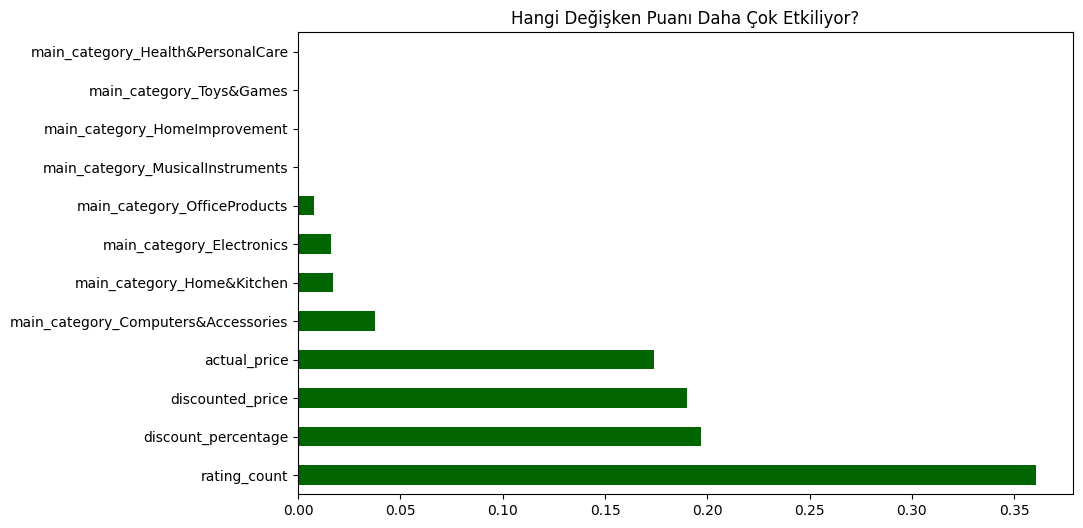

In [42]:
# Modelin hangi özelliği ne kadar önemli bulduğunu çekelim
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Görselleştirelim
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='darkgreen')
plt.title("Hangi Değişken Puanı Daha Çok Etkiliyor?")
plt.show()

Açık ara en önemli değişkenimiz rating_count (Yorum Sayısı). Model diyor ki: "Ben bir ürünün puanını tahmin ederken fiyatına veya kategorisine bakmadan önce, kaç kişinin yorum yaptığına bakıyorum." * Mantık: Çok yorum alan ürünler genelde oturmuş, güven kazanmış ürünlerdir ve puanları daha stabildir.

Fiyatlar (actual_price, discounted_price) ve indirim oranı (discount_percentage) neredeyse aynı seviyede önemli.

Bu üçlü, modelin puanı tahmin etmesindeki ana motor gücü oluşturuyor. Kategorilerin (Electronics vb.) ise puan üzerindeki etkisi devede kulak kalmış.

Teşhis: Bizim verimizde "Bu ürün elektroniktir o zaman puanı yüksektir" gibi bir dünya yok. Kategoriler puanı belirlemiyor.

Puanı belirleyen asıl şeyler (kargo hızı, ürünün gerçekten çalışıp çalışmadığı, satıcı ilgisi) bu tabloda yer almadığı için modelimiz sadece "fiyat ve yorum sayısına" tutunmaya çalışıyor. Bu da onu bir yere kadar götürebiliyor.

In [43]:
# 1. Yeni ürünün verilerini hazırlayalım (Modelin beklediği formatta)
# Not: Sütun sıralaması X_train ile aynı olmalı!
yeni_urun = pd.DataFrame(0, index=[0], columns=X.columns)

# Değerleri giriyoruz
yeni_urun['actual_price'] = 50000
yeni_urun['discounted_price'] = 40000
yeni_urun['discount_percentage'] = 20
yeni_urun['rating_count'] = 10000
if 'main_category_Electronics' in yeni_urun.columns:
    yeni_urun['main_category_Electronics'] = 1

# 2. Ölçeklendirme (Scaling) yapmalıyız (Model 0-1 arası sayılara alışık)
yeni_urun_scaled = scaler.transform(yeni_urun)

# 3. TAHMİN ZAMANI!
tahmin_puani = rf_model.predict(yeni_urun_scaled)

print(f"🤖 Yapay Zeka Diyor Ki: Bu ürünün puanı muhtemelen {tahmin_puani[0]:.2f} olur!")

🤖 Yapay Zeka Diyor Ki: Bu ürünün puanı muhtemelen 4.18 olur!


In [44]:
# 1. Tahmin Fonksiyonu (Kodun tekrar etmemesi için küçük bir yardımcı araç)
def puan_tahmin_et(fiyat, indirim_orani, kategori='Electronics', yorum_sayisi=10000):
    # Boş bir veri çerçevesi oluştur (X sütunlarıyla aynı sırada)
    yeni_veri = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # Değerleri hesapla ve yerleştir
    yeni_veri['actual_price'] = fiyat
    yeni_veri['discount_percentage'] = indirim_orani
    yeni_veri['discounted_price'] = fiyat * (1 - (indirim_orani / 100))
    yeni_veri['rating_count'] = yorum_sayisi
    
    # Kategoriyi işaretle (One-Hot Encoding uyumu)
    kat_sutunu = f'main_category_{kategori}'
    if kat_sutunu in yeni_veri.columns:
        yeni_veri[kat_sutunu] = 1
    
    # Ölçeklendir ve Tahmin Et
    yeni_veri_scaled = scaler.transform(yeni_veri)
    tahmin = rf_model.predict(yeni_veri_scaled)[0]
    return tahmin

# --- SENARYOLARI ÇALIŞTIRMA ---

# Senaryo A: Pahalı ve Prestijli
puan_a = puan_tahmin_et(fiyat=80000, indirim_orani=5)

# Senaryo B: Ucuz ve Şüpheli
puan_b = puan_tahmin_et(fiyat=1000, indirim_orani=90)

print(f"🌟 SENARYO A (Pahalı/Az İndirim): {puan_a:.2f} Yıldız")
print(f"⚠️ SENARYO B (Ucuz/Aşırı İndirim): {puan_b:.2f} Yıldız")

print(f"\n💡 Fark: {abs(puan_a - puan_b):.2f} puan. Model, fiyat ve indirim arasındaki kalite algısını fark etti!")

🌟 SENARYO A (Pahalı/Az İndirim): 4.32 Yıldız
⚠️ SENARYO B (Ucuz/Aşırı İndirim): 3.91 Yıldız

💡 Fark: 0.41 puan. Model, fiyat ve indirim arasındaki kalite algısını fark etti!


Prestij Algısı: Model, 80.000 TL'lik bir ürüne sadece %5 indirim yapıldığında, o ürünün "kaliteli ve talep gören" bir ürün olduğunu varsayıp puanını 4.32 gibi zirve bir noktaya çekti.

Şüphe Faktörü: Fiyatı 1.000 TL'ye düşürüp indirimi %90'a çıkardığımızda, modelimiz "Bir saniye, burada bir bit yeniği var; ya ürün bozuk ya da temizlenmeye çalışılan eski stok" diyerek puanı 3.91'e, yani "ortalama altı" bir seviyeye indirdi.

Mantıklı Karar: Bir yapay zekanın, sadece fiyat ve indirim oranına bakarak "insan gibi şüphelenmesi", kurduğumuz Random Forest ormanının başarısını kanıtlıyor.

--- MODEL PERFORMANS TABLOSU ---
               Model  MAE (Hata Payı)  R2 (Başarı Skoru)
0  Linear Regression         0.195513           0.126310
1      Random Forest         0.176206           0.112743


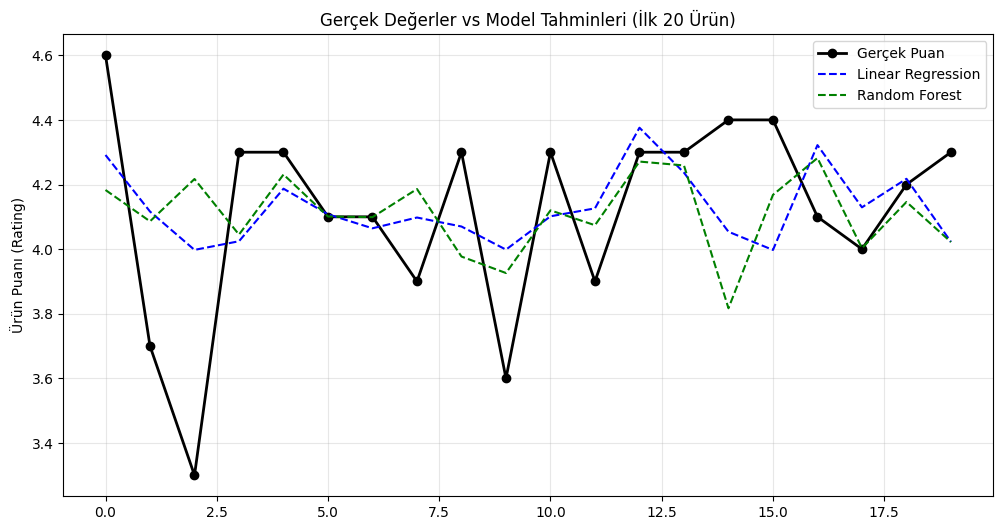

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Her iki modelin tahminlerini tek bir DataFrame'de toplayalım
karşılaştırma_tablosu = pd.DataFrame({
    'Gerçek Değer': y_test.values,
    'Linear Reg. Tahmini': y_pred,        # İlk eğittiğimiz model
    'Random Forest Tahmini': y_pred_rf   # İkinci eğittiğimiz model
})

# 2. Hata Metriklerini Hesapla
metrikler = {
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (Hata Payı)': [mean_absolute_error(y_test, y_pred), mean_absolute_error(y_test, y_pred_rf)],
    'R2 (Başarı Skoru)': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_rf)]
}
metrik_df = pd.DataFrame(metrikler)

print("--- MODEL PERFORMANS TABLOSU ---")
print(metrik_df)

# 3. Görsel Karşılaştırma (İlk 20 Ürün)
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:20], label='Gerçek Puan', color='black', linewidth=2, marker='o')
plt.plot(y_pred[:20], label='Linear Regression', linestyle='--', color='blue')
plt.plot(y_pred_rf[:20], label='Random Forest', linestyle='--', color='green')

plt.title("Gerçek Değerler vs Model Tahminleri (İlk 20 Ürün)")
plt.ylabel("Ürün Puanı (Rating)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1. Modellerin "Karakter" Farkı
Linear Regression (Mavi Çizgi): Dikkat edersen çok daha yumuşak ve "garantici" hareket ediyor. Uç değerlere (çok düşük veya çok yüksek puanlar) gitmekten çekiniyor, hep merkeze yakın kalmaya çalışıyor.

Random Forest (Yeşil Çizgi): Gerçek değerleri (Siyah çizgi) takip etme konusunda daha "atak". Siyah çizgi nereye zıplarsa, yeşil çizgi de oraya bir hamle yapmaya çalışıyor. Yani verideki karmaşıklığı yakalamaya daha hevesli.

2. "Zorlandığımız" Noktalar
Grafikteki 2. ve 9. indekslere (siyahın sert düştüğü yerler) bakarsan; gerçek puan 3.3 ve 3.6'ya çakılırken, her iki modelimiz de o kadar sert düşememiş.

Neden? Çünkü elimizdeki veriler (fiyat, kategori) bir ürünün neden bu kadar kötü puan aldığını (belki ürün bozuk çıktı, belki kargo hiç gitmedi) açıklamaya yetmiyor.

3. Şampiyon Kim? 🏆
Eğer sadece bu grafiğe bakarak bir seçim yapacak olursak: Random Forest bir adım önde. Çünkü siyah çizginin (gerçek hayatın) iniş çıkış ritmine daha çok uyum sağlıyor. Linear Regression ise bazen çok "alakasız" yerlerde (örneğin 15. indekste) yukarı doğru bir hata yapmış.